In [1]:
import glob
import numpy as np
import scipy.signal as scs
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import CESfunctionsIASC as cf

In [22]:
Imeases = sorted(glob.glob('./360/Imeas*.npy'))
Ibes = sorted(glob.glob('./360/Ib*.txt'))
Mes = sorted(glob.glob('./360/M*.txt'))
MCes = sorted(glob.glob('./CRDS/MC*.txt'))

In [23]:
print(Imeases,Ibes,Mes,MCes)

['./360/Imeas2507101744.npy', './360/Imeas2507111530.npy', './360/Imeas2507301721.npy', './360/Imeas2507311529.npy', './360/Imeas2508011944.npy'] ['./360/Ib2507101436.txt', './360/Ib2507111042.txt', './360/Ib2507301327.txt', './360/Ib2507311156.txt', './360/Ib2508011023.txt'] ['./360/M2507101744.txt', './360/M2507111530.txt', './360/M2507301721.txt', './360/M2507311529.txt', './360/M2508011944.txt'] ['./CRDS/MC2507101758.txt', './CRDS/MC2507111529.txt', './CRDS/MC2507301638.txt', './CRDS/MC2507301745.txt', './CRDS/MC2507311533.txt', './CRDS/MC2508011240.txt']


In [24]:
k=0
Ibfile = Ibes[k]
Imeasfile = Imeases[k]
Mfile = Mes[k]
colsM = ['time','no2','hono']
MCfile = MCes[k]
colsMC = ['time','no2','tau','pres','temp','f_s','f_p','flag']

In [4]:
Ib = np.loadtxt(Ibfile)
Imeas = np.load(Imeasfile)
Mdf = pd.read_csv(Mfile, sep=' ', header=None, skiprows=2,encoding='utf-8',
                 names=colsM,
                 index_col='time',parse_dates=['time']
                )
MCdf = pd.read_csv(MCfile, sep=' ', header=None, skiprows=2,encoding='utf-8',
                 names=colsMC,
                 index_col='time',parse_dates=['time']
                )

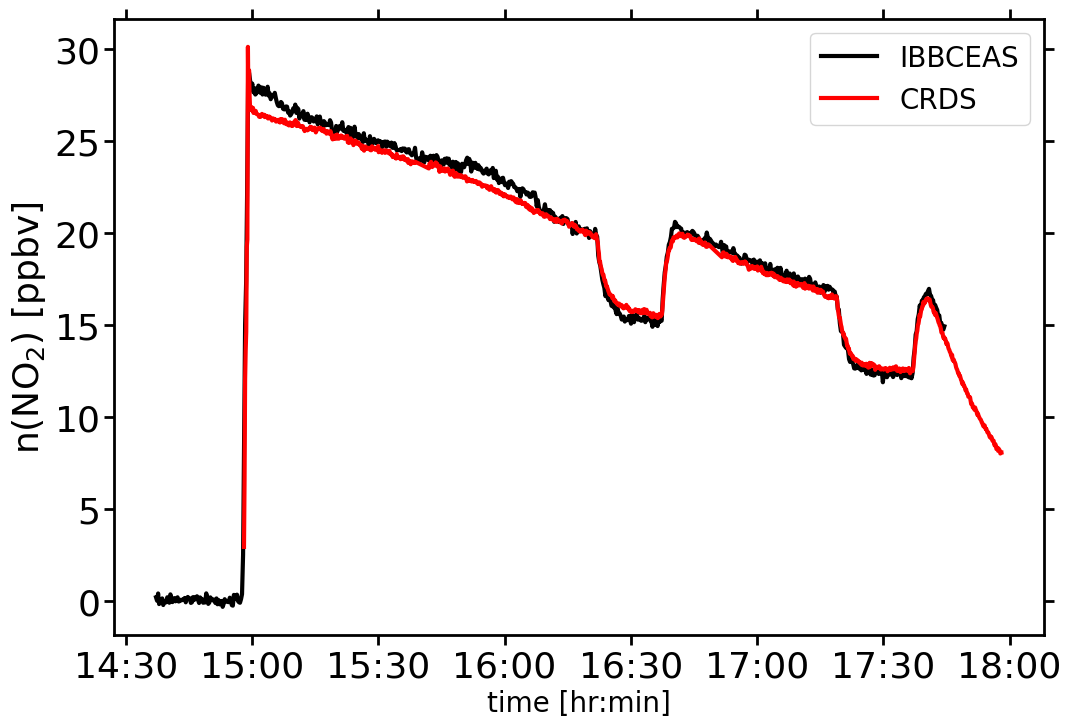

In [21]:
f = plt.figure(figsize=(12,8))
ax1 = f.add_subplot(111)
ax1.plot(Mdf.index,Mdf.no2*.95,'-k',linewidth=3.0,alpha=1, label="IBBCEAS")
ax1.plot(MCdf[MCdf.no2 >= 2].index,MCdf[MCdf.no2 >= 2].no2,'-r',linewidth=3.0,alpha=1, label="CRDS")

#rect1=plt.Rectangle(xy=(dt.datetime(2024,4,10,10,30),-1), width=dt.timedelta(hours=3.5), height=35, 
                    #edgecolor='k', facecolor='k', alpha=0.2, linewidth=1)
#ax1.add_patch(rect1)


#rect2=plt.Rectangle(xy=(dt.datetime(2024,4,10,15,30),-1), width=dt.timedelta(hours=2), height=35, 
                    #edgecolor='k', facecolor='k', alpha=0.2, linewidth=1)
#ax1.add_patch(rect2)


#ax1.set_xlim(625,700)
#ax1.set_ylim(8,32)


ax1.xaxis.set_major_formatter(DateFormatter("%H:%M"))
ax1.set_xlabel('time [hr:min]',size=20)
ax1.set_ylabel('n(NO$_2$) [ppbv]',size=26)
#ax1.set_xlabel('Wavelength [nm]',size=26)
#ax1.set_ylabel('ext [cm$^{-1}$]',size=20)
#ax1.set_title("NO$_2$ measurements, 24/04",size=16)

#ax1.legend(fontsize=26, loc='upper right', bbox_to_anchor=(0.94, 0.99))
ax1.legend(fontsize=20, loc='upper right')

ax1.tick_params(which='both', width=2)
ax1.tick_params(which='major', length=7,labelsize=26,top=True, right=True)
ax1.tick_params(which='minor', length=4,top=True, right=True)
#ax1.xaxis.set_minor_locator(AutoMinorLocator(3))
#ax1.yaxis.set_minor_locator(AutoMinorLocator())
#plt.vlines(dt.datetime(2024,4,10,14,0),0,50, colors='k', linestyles= 'dashed')
#plt.vlines(dt.datetime(2024,4,10,15,30),0,50, colors='k', linestyles= 'dashed')
ax1.yaxis.offsetText.set_fontsize(22)
ax1.ticklabel_format(axis='y', style='sci',useMathText=True)

for axis in ['top', 'bottom', 'left', 'right']:
    ax1.spines[axis].set_linewidth(2)

#ax1.grid()
#plt.savefig("no3_resonanceIs.png",bbox_inches='tight')

In [25]:
Mrfile = Mes[k][:-4]+'_r.dat'
colsMr = ['time','no2','hono']

In [26]:
Mrdf = pd.read_csv(Mrfile, sep=' ', header=None, skiprows=2,encoding='utf-8',
                 names=colsMr,
                 index_col='time',parse_dates=['time']
                )

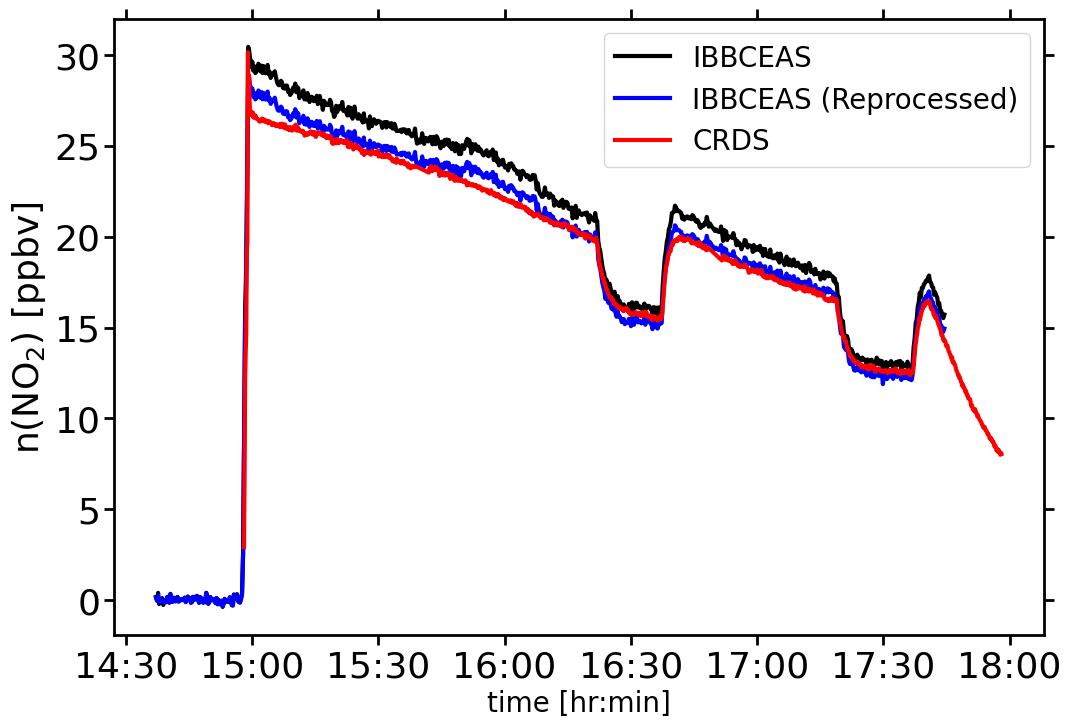

In [27]:
f = plt.figure(figsize=(12,8))
ax1 = f.add_subplot(111)
ax1.plot(Mdf.index,Mdf.no2,'-k',linewidth=3.0,alpha=1, label="IBBCEAS")
ax1.plot(Mrdf.index,Mrdf.no2,'-b',linewidth=3.0,alpha=1, label="IBBCEAS (Reprocessed)")
ax1.plot(MCdf[MCdf.no2 >= 2].index,MCdf[MCdf.no2 >= 2].no2,'-r',linewidth=3.0,alpha=1, label="CRDS")

#rect1=plt.Rectangle(xy=(dt.datetime(2024,4,10,10,30),-1), width=dt.timedelta(hours=3.5), height=35, 
                    #edgecolor='k', facecolor='k', alpha=0.2, linewidth=1)
#ax1.add_patch(rect1)


#rect2=plt.Rectangle(xy=(dt.datetime(2024,4,10,15,30),-1), width=dt.timedelta(hours=2), height=35, 
                    #edgecolor='k', facecolor='k', alpha=0.2, linewidth=1)
#ax1.add_patch(rect2)


#ax1.set_xlim(625,700)
#ax1.set_ylim(8,32)


ax1.xaxis.set_major_formatter(DateFormatter("%H:%M"))
ax1.set_xlabel('time [hr:min]',size=20)
ax1.set_ylabel('n(NO$_2$) [ppbv]',size=26)
#ax1.set_xlabel('Wavelength [nm]',size=26)
#ax1.set_ylabel('ext [cm$^{-1}$]',size=20)
#ax1.set_title("NO$_2$ measurements, 24/04",size=16)

#ax1.legend(fontsize=26, loc='upper right', bbox_to_anchor=(0.94, 0.99))
ax1.legend(fontsize=20, loc='upper right')

ax1.tick_params(which='both', width=2)
ax1.tick_params(which='major', length=7,labelsize=26,top=True, right=True)
ax1.tick_params(which='minor', length=4,top=True, right=True)
#ax1.xaxis.set_minor_locator(AutoMinorLocator(3))
#ax1.yaxis.set_minor_locator(AutoMinorLocator())
#plt.vlines(dt.datetime(2024,4,10,14,0),0,50, colors='k', linestyles= 'dashed')
#plt.vlines(dt.datetime(2024,4,10,15,30),0,50, colors='k', linestyles= 'dashed')
ax1.yaxis.offsetText.set_fontsize(22)
ax1.ticklabel_format(axis='y', style='sci',useMathText=True)

for axis in ['top', 'bottom', 'left', 'right']:
    ax1.spines[axis].set_linewidth(2)

#ax1.grid()
#plt.savefig("no3_resonanceIs.png",bbox_inches='tight')

In [10]:
MCdf[MCdf.no2 != 0].index

DatetimeIndex(['2025-07-10 14:32:14', '2025-07-10 14:32:22',
               '2025-07-10 14:32:30', '2025-07-10 14:32:38',
               '2025-07-10 14:32:46', '2025-07-10 14:32:54',
               '2025-07-10 14:33:02', '2025-07-10 14:33:10',
               '2025-07-10 14:33:18', '2025-07-10 14:33:26',
               ...
               '2025-07-10 17:56:52', '2025-07-10 17:57:00',
               '2025-07-10 17:57:08', '2025-07-10 17:57:16',
               '2025-07-10 17:57:24', '2025-07-10 17:57:32',
               '2025-07-10 17:57:40', '2025-07-10 17:57:48',
               '2025-07-10 17:57:56', '2025-07-10 17:58:04'],
              dtype='datetime64[ns]', name='time', length=1500, freq=None)